In [3]:
import tensorflow as tf
from google.colab import files
uploaded = files.upload()


Saving firstml.zip to firstml.zip


In [4]:
import os
print(os.listdir())

['.config', 'firstml.zip', 'sample_data']


In [5]:
!unzip firstml.zip

Archive:  firstml.zip
   creating: Custom Dataset 1/
   creating: Custom Dataset 1/cups/
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.44.26 (1).jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.44.26.jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.44.27 (1).jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.44.27.jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.44.28 (1).jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.44.28 (2).jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.44.28.jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.45.18.jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.45.24.jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.45.53.jpeg  
  inflating: Custom Dataset 1/cups/WhatsApp Image 2026-06-10 at 18.48.52.jpeg  
  inflating: Cu

In [6]:
print(os.listdir("Custom Dataset 1"))

['cups', 'handgestures', 'unoflipcards']


In [7]:
import tensorflow as tf
train_dataset =tf.keras.utils.image_dataset_from_directory(
    'Custom Dataset 1',
    validation_split=0.2,
    subset= 'training',
    seed =123,
    image_size=(64,64),
    batch_size=32
)
val_dataset= tf.keras.utils.image_dataset_from_directory(
    'Custom Dataset 1',
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(64,64),
    batch_size=32
)

Found 77 files belonging to 3 classes.
Using 62 files for training.
Found 77 files belonging to 3 classes.
Using 15 files for validation.


In [8]:
print(train_dataset.class_names)

['cups', 'handgestures', 'unoflipcards']


In [10]:
#EPOCHS = 10 , NO DROPOUTS
model1 = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(64,64,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,443 (6.03 MB)

 Trainable params: 1,581,443 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model1.compile(
    optimizer ='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history1 = model1.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 970ms/step - accuracy: 0.6129 - loss: 2.3911 - val_accuracy: 0.5333 - val_loss: 1.1613
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 597ms/step - accuracy: 0.5968 - loss: 1.0033 - val_accuracy: 0.3333 - val_loss: 2.9441
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step - accuracy: 0.5806 - loss: 1.1249 - val_accuracy: 0.7333 - val_loss: 0.7774
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step - accuracy: 0.6935 - loss: 0.8749 - val_accuracy: 0.4667 - val_loss: 1.0251
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step - accuracy: 0.7419 - loss: 0.5708 - val_accuracy: 0.5333 - val_loss: 1.2749
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step - accuracy: 0.7419 - loss: 0.5421 - val_accuracy: 0.4000 - val_loss: 1.9338
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step - accuracy: 0.8871 - loss: 0.3665 - val_accuracy: 0.6667 - val_loss: 0.8685
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step - accuracy: 0.9355 - loss: 0.2607 - val_accuracy: 0.4000 - val_loss:

In [12]:
import tensorflow as tf
from google.colab import files
uploaded = files.upload()


Saving WhatsApp Image 2026-06-12 at 12.09.40.jpeg to WhatsApp Image 2026-06-12 at 12.09.40.jpeg
Saving WhatsApp Image 2026-06-12 at 10.47.40 (2).jpeg to WhatsApp Image 2026-06-12 at 10.47.40 (2).jpeg
Saving WhatsApp Image 2026-06-12 at 10.47.40 (1).jpeg to WhatsApp Image 2026-06-12 at 10.47.40 (1).jpeg
Saving WhatsApp Image 2026-06-12 at 10.47.40.jpeg to WhatsApp Image 2026-06-12 at 10.47.40.jpeg
Saving WhatsApp Image 2026-06-12 at 10.38.07.jpeg to WhatsApp Image 2026-06-12 at 10.38.07.jpeg
Saving WhatsApp Image 2026-06-10 at 22.30.06.jpeg to WhatsApp Image 2026-06-10 at 22.30.06.jpeg


In [37]:
import os
print(os.listdir())

['.config', 'WhatsApp Image 2026-06-12 at 12.09.40.jpeg', 'firstml.zip', 'WhatsApp Image 2026-06-12 at 10.47.40 (1).jpeg', 'WhatsApp Image 2026-06-10 at 22.30.06.jpeg', 'WhatsApp Image 2026-06-12 at 10.47.40.jpeg', 'WhatsApp Image 2026-06-12 at 10.38.07.jpeg', 'Custom Dataset 1', 'WhatsApp Image 2026-06-12 at 10.47.40 (2).jpeg', 'sample_data']


In [36]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img = load_img('WhatsApp Image 2026-06-10 at 22.30.06.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model1.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# the image is not in the dataset but is a pretty similar one, different background, model did good
# correct prediction


img = load_img('WhatsApp Image 2026-06-12 at 10.38.07.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model1.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image but very similar background and same cup pattern
# correct prediction

img = load_img('WhatsApp Image 2026-06-12 at 10.47.40.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model1.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# a bright red cup, none like in dataset, model is picking a random probability
# wrong prediction
# epochs =10, wrong prediction by a very large margin, i don't know why its not more equal
# Predicted: unoflipcards


img = load_img('WhatsApp Image 2026-06-12 at 10.47.40 (1).jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model1.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image for hand gestures, but with 2 hands this time, unlike in dataset
# wrong prediction

img = load_img('WhatsApp Image 2026-06-12 at 10.47.40 (2).jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model1.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image of unoflipcards
# correct prediction

img = load_img('WhatsApp Image 2026-06-12 at 12.09.40.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model1.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image of hand gestures
# wrong prediction (by a large margin, i don't understand because this one was pretty similar still)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
[[0.00543742 0.9124544  0.08210813]]
Predicted: handgestures
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[9.9653459e-01 8.3263573e-04 2.6327511e-03]]
Predicted: cups
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[1.5085033e-04 4.0780120e-02 9.5906895e-01]]
Predicted: unoflipcards
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.59120846 0.15998347 0.24880807]]
Predicted: cups
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[0.10716559 0.22172618 0.6711082 ]]
Predicted: unoflipcards
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.06713708 0.04682002 0.88604295]]
Predicted: unoflipcards


In [27]:
#EPOCHS = 20 ,  DROPOUTS

model2 = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(64,64,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation='softmax')
])
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,443 (6.03 MB)

 Trainable params: 1,581,443 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model2.compile(
    optimizer ='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history2 = model2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 767ms/step - accuracy: 0.6774 - loss: 0.7328 - val_accuracy: 0.6667 - val_loss: 0.9783
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step - accuracy: 0.6129 - loss: 0.8741 - val_accuracy: 0.8000 - val_loss: 0.7364
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step - accuracy: 0.7097 - loss: 0.6813 - val_accuracy: 0.5333 - val_loss: 1.0655
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.7419 - loss: 0.7181 - val_accuracy: 0.4667 - val_loss: 1.0912
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step - accuracy: 0.6452 - loss: 0.8365 - val_accuracy: 0.7333 - val_loss: 0.8201
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step - accuracy: 0.7903 - loss: 0.5558 - val_accuracy: 0.5333 - val_loss: 0.8459
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step - accuracy: 0.6613 - loss: 0.6942 - val_accuracy: 0.5333 - val_loss: 0.9350
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step - accuracy: 0.7903 - loss: 0.5259 - val_accuracy: 0.5333 - val_loss: 0.

In [40]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img = load_img('WhatsApp Image 2026-06-10 at 22.30.06.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# the image is not in the dataset but is a pretty similar one, different background, model did good
# correct prediction


img = load_img('WhatsApp Image 2026-06-12 at 10.38.07.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image but very similar background and same cup pattern
# correct prediction

img = load_img('WhatsApp Image 2026-06-12 at 10.47.40.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# a bright red cup, none like in dataset, model is picking a random probability
# wrong prediction
# epochs =20, wrong prediction by a very large margin, i don't know why its not more equal
# Predicted: unoflipcards


img = load_img('WhatsApp Image 2026-06-12 at 10.47.40 (1).jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image for hand gestures, but with 2 hands this time, unlike in dataset
# wrong prediction

img = load_img('WhatsApp Image 2026-06-12 at 10.47.40 (2).jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image of unoflipcards
# wrong prediction

img = load_img('WhatsApp Image 2026-06-12 at 12.09.40.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image of hand gestures
# wrong prediction (by a large margin, i don't understand because this one was pretty similar still)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[0.09685924 0.69994974 0.20319104]]
Predicted: handgestures
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[9.980236e-01 1.286291e-03 6.900556e-04]]
Predicted: cups
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[0.00923426 0.04119146 0.94957435]]
Predicted: unoflipcards
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.4862668  0.06891022 0.44482303]]
Predicted: cups
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[0.15199135 0.19191156 0.65609705]]
Predicted: unoflipcards
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.1219919  0.05161567 0.8263924 ]]
Predicted: unoflipcards


In [31]:
#EPOCHS = 20 , NO DROPOUTS

model3 = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(64,64,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,443 (6.03 MB)

 Trainable params: 1,581,443 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model3.compile(
    optimizer ='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history3 = model3.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 761ms/step - accuracy: 0.8065 - loss: 2.1191 - val_accuracy: 0.6000 - val_loss: 1.2254
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6290 - loss: 1.0182 - val_accuracy: 0.4000 - val_loss: 4.6320
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 905ms/step - accuracy: 0.6774 - loss: 1.4140 - val_accuracy: 0.2667 - val_loss: 2.1083
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step - accuracy: 0.9677 - loss: 0.1307 - val_accuracy: 0.7333 - val_loss: 1.3246
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step - accuracy: 0.7903 - loss: 0.4040 - val_accuracy: 0.7333 - val_loss: 1.2419
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step - accuracy: 0.8710 - loss: 0.2630 - val_accuracy: 0.6000 - val_loss: 1.1514
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step - accuracy: 1.0000 - loss: 0.0521 - val_accuracy: 0.3333 - val_loss: 2.2143
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.9677 - loss: 0.1777 - val_accuracy: 0.4000 - val_loss: 2.179

In [43]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img = load_img('WhatsApp Image 2026-06-10 at 22.30.06.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# the image is not in the dataset but is a pretty similar one, different background, model did good
# correct prediction


img = load_img('WhatsApp Image 2026-06-12 at 10.38.07.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image but very similar background and same cup pattern
# correct prediction

img = load_img('WhatsApp Image 2026-06-12 at 10.47.40.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# a bright red cup, none like in dataset, model is picking a random probability
# wrong prediction
# epochs =20, wrong prediction by a very large margin, i don't know why its not more equal
# Predicted: unoflipcards


img = load_img('WhatsApp Image 2026-06-12 at 10.47.40 (1).jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image for hand gestures, but with 2 hands this time, unlike in dataset
# wrong prediction

img = load_img('WhatsApp Image 2026-06-12 at 10.47.40 (2).jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image of unoflipcards
# wrong prediction

img = load_img('WhatsApp Image 2026-06-12 at 12.09.40.jpeg', target_size=(64, 64))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

predictions = model2.predict(img_array)
print(predictions)

class_names = train_dataset.class_names
predicted_class = class_names[np.argmax(predictions)]
print(f"Predicted: {predicted_class}")
# new image of hand gestures
# wrong prediction (by a large margin, i don't understand because this one was pretty similar still)

#all last 3 images predicted cups this time as the wrong prediction, unlike when epochs were 10 and no dropouts, maybe it is because cups are the first class

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.09685924 0.69994974 0.20319104]]
Predicted: handgestures
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[9.980236e-01 1.286291e-03 6.900556e-04]]
Predicted: cups
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.00923426 0.04119146 0.94957435]]
Predicted: unoflipcards
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[0.4862668  0.06891022 0.44482303]]
Predicted: cups
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[[0.15199135 0.19191156 0.65609705]]
Predicted: unoflipcards
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[0.1219919  0.05161567 0.8263924 ]]
Predicted: unoflipcards


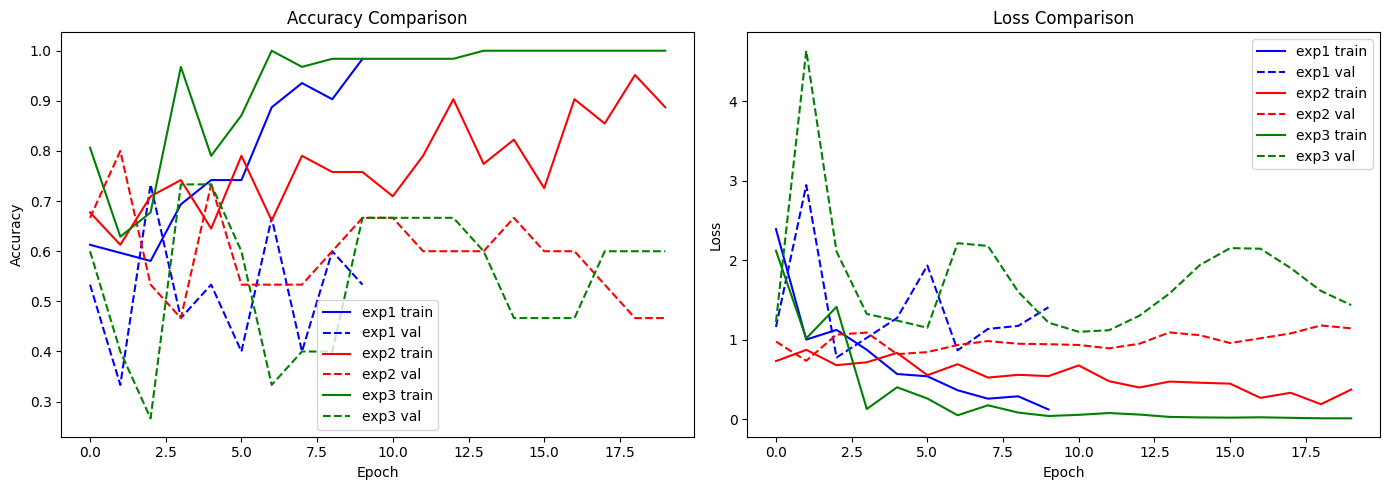

In [44]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history1.history['accuracy'], label='exp1 train', color='blue')
axes[0].plot(history1.history['val_accuracy'], label='exp1 val', color='blue', linestyle='dashed')
axes[0].plot(history2.history['accuracy'], label='exp2 train', color='red')
axes[0].plot(history2.history['val_accuracy'], label='exp2 val', color='red', linestyle='dashed')
axes[0].plot(history3.history['accuracy'], label='exp3 train', color='green')
axes[0].plot(history3.history['val_accuracy'], label='exp3 val', color='green', linestyle='dashed')
axes[0].set_title('Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(history1.history['loss'], label='exp1 train', color='blue')
axes[1].plot(history1.history['val_loss'], label='exp1 val', color='blue', linestyle='dashed')
axes[1].plot(history2.history['loss'], label='exp2 train', color='red')
axes[1].plot(history2.history['val_loss'], label='exp2 val', color='red', linestyle='dashed')
axes[1].plot(history3.history['loss'], label='exp3 train', color='green')
axes[1].plot(history3.history['val_loss'], label='exp3 val', color='green', linestyle='dashed')
axes[1].set_title('Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('experiment_results.png')  # saves the plot
plt.show()